# Post-processing: Baseline vs Proposed Hierarchical Resilient Control (Two-building community)

This notebook loads the two 1-day time-series CSV files and computes key evaluation metrics:

- **Feeder-limit compliance** (80% of `feeder_capacity_kW`)
- **Aggregate feeder power variability** (std, CV, ramps)
- **Building-level thermal comfort** (occupied unmet degree-hours relative to 24°C)
- **TES utilization** (SOC statistics, charge/discharge hours, SOC bound violations)
- **Requested plots** (zone temperatures, power, SOC)

**Inputs**
- Baseline: `scenario1_metrics_20260102_090125.csv`
- Proposed: `scenario2_metrics_20260102_090125.csv`

Assumptions:
- `sim_hours` is in hours with ~0.25 h steps (15 minutes).
- Occupied hours: **7:00–19:00** (unoccupied shown as grey shading).
- Zone temperature setpoint for plotting/comfort metric: **24°C**.


## Before move forward, let's post-process the HIL measurement data of building A under VAV device reinitialization attack (core zone)

In [158]:
import pandas as pd

# ====== User inputs ======
xlsx_path = r"hil_measurement_buildingA.xlsx"  # your local file
source_sheet = 0                              # first sheet (5-min data)
target_sheet_name = "15min"                   # second sheet name
agg_method = "mean"                           # "mean", "sum", or "first"
# =========================

time_col = "time [hour]"

# Read 5-min data
df = pd.read_excel(xlsx_path, sheet_name=source_sheet)

if time_col not in df.columns:
    raise ValueError(f"Expected '{time_col}' in columns, got: {list(df.columns)}")

# Sort by time and build timedelta index
df = df.sort_values(time_col).reset_index(drop=True)
df["__td__"] = pd.to_timedelta(df[time_col], unit="h")
df = df.set_index("__td__")

# Drop time column before resampling to avoid duplication
df = df.drop(columns=[time_col])

# Resample to 15 minutes
if agg_method == "mean":
    df_15 = df.resample("15min").mean(numeric_only=True)
elif agg_method == "sum":
    df_15 = df.resample("15min").sum(numeric_only=True)
elif agg_method == "first":
    df_15 = df.resample("15min").first()
else:
    raise ValueError("agg_method must be one of: 'mean', 'sum', 'first'")

# Restore time [hour] from index
df_15 = df_15.reset_index()
df_15[time_col] = df_15["__td__"].dt.total_seconds() / 3600.0
df_15 = df_15.drop(columns=["__td__"])

# Put time [hour] as first column
cols = [time_col] + [c for c in df_15.columns if c != time_col]
df_15 = df_15[cols]

# Add Total_power_meas [kW] based on Total_power_meas [W]
w_col = "Total_power_meas [W]"
kw_col = "Total_power_meas [kW]"

if w_col in df_15.columns:
    df_15[kw_col] = df_15[w_col] / 1000.0

    # Place kW column right after the W column
    w_idx = df_15.columns.get_loc(w_col)
    cols = df_15.columns.tolist()
    cols.remove(kw_col)
    cols.insert(w_idx + 1, kw_col)
    df_15 = df_15[cols]
else:
    raise ValueError(f"Column '{w_col}' not found in the 15-min sheet columns: {list(df_15.columns)}")

# Write to the same workbook as the second sheet (replace if exists)
with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_15.to_excel(writer, sheet_name=target_sheet_name, index=False)

print(f"Done. Wrote 15-min data + kW column to sheet '{target_sheet_name}' in:\n{xlsx_path}")


Done. Wrote 15-min data + kW column to sheet '15min' in:
hil_measurement_buildingA.xlsx


## Baseline vs Proposed Hierarchical Resilient Control (Two-building community)

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# baseline_path = Path(r"scenario1_metrics_20260102_090125.csv")
# proposed_path = Path(r"scenario2_metrics_20260102_090125.csv")

# baseline_path = Path(r"scenario1_metrics_20260121_203408.csv")
# proposed_path = Path(r"scenario2_metrics_20260121_203408.csv")

baseline_path = Path(r"scenario1_metrics_20260121_210859.csv")
proposed_path = Path(r"scenario2_metrics_20260121_210859.csv")



df_base = pd.read_csv(baseline_path)
df_prop = pd.read_csv(proposed_path)

# Strip any whitespace in headers
df_base.columns = [c.strip() for c in df_base.columns]
df_prop.columns = [c.strip() for c in df_prop.columns]

# Sort by time
df_base = df_base.sort_values("sim_hours").reset_index(drop=True)
df_prop = df_prop.sort_values("sim_hours").reset_index(drop=True)

def infer_dt(df):
    diffs = np.diff(df["sim_hours"].values)
    diffs = diffs[diffs > 0]
    return float(np.median(diffs)) if len(diffs) else 0.25

dt = float(np.median([infer_dt(df_base), infer_dt(df_prop)]))
print("Inferred timestep (hours):", dt)

required_cols = ['sim_hours', 'P_total_kW', 'feeder_capacity_kW', 'P_A_kW', 'P_B_kW', 'SOC_B', 'T_core_A', 'T_east_A', 'T_north_A', 'T_south_A', 'T_west_A', 'T_core_B', 'T_east_B', 'T_north_B', 'T_south_B', 'T_west_B']
missing_base = [c for c in required_cols if c not in df_base.columns]
missing_prop = [c for c in required_cols if c not in df_prop.columns]
if missing_base or missing_prop:
    raise ValueError(
        f"Missing required columns.\nBaseline missing: {missing_base}\nProposed missing: {missing_prop}"
    )

df_base.head()


Inferred timestep (hours): 0.25


,timestamp,sim_hours,P_A_kW,comfort_violation_A_degCh,T_core_A,T_east_A,T_north_A,T_south_A,T_west_A,scheduled_vars_A,...,T_west_B,scheduled_vars_B,under_attack_B,P_total_kW,feeder_capacity_kW,feeder_utilization_pct,feeder_margin_kW,feeder_violated,attack_active,attack_name
0,18316800,0.00,0.049,0,23.888889,23.759259,23.574074,23.166667,23.425926,"bcp,bahu",...,23.901708,NaN,False,0.049,50,1.820000e-10,30.0,False,False,NaN
1,18317700,0.25,0.049,0,24.000000,23.759259,23.796296,23.648148,23.740741,"bcp,bahu",...,23.901708,NaN,False,0.049,50,1.660000e-10,30.0,False,False,NaN
2,18318600,0.50,0.049,0,24.000000,23.833333,23.888889,23.740741,23.851852,"bcp,bahu",...,23.901708,NaN,False,0.049,50,1.660000e-10,30.0,False,False,NaN
3,18319500,0.75,0.049,0,24.037037,23.833333,23.925926,23.814815,23.888889,"bcp,bahu",...,23.901708,NaN,False,0.049,50,1.810000e-10,30.0,False,False,NaN
4,18320400,1.00,0.049,0,24.055556,23.833333,23.888889,23.833333,23.888889,"bcp,bahu",...,23.866630,NaN,False,0.049,50,1.760000e-10,30.0,False,False,NaN


## Helper functions (metrics + plots)

In [160]:

ZONE_COLS_A = ["T_core_A", "T_east_A", "T_north_A", "T_south_A", "T_west_A"]
ZONE_COLS_B = ["T_core_B", "T_east_B", "T_north_B", "T_south_B", "T_west_B"]

def occupied_mask(sim_hours, occ_start=7.0, occ_end=19.0):
    h = np.asarray(sim_hours)
    return (h >= occ_start) & (h < occ_end)

def feeder_metrics(df, dt_hours, limit_frac=0.8):
    cap = df["feeder_capacity_kW"].to_numpy(dtype=float)
    p = df["P_total_kW"].to_numpy(dtype=float)
    limit = limit_frac * cap
    exceed = np.maximum(p - limit, 0.0)
    viol = exceed > 0
    return {
        "feeder_capacity_mean_kW": float(np.mean(cap)),
        "feeder_limit_mean_kW": float(np.mean(limit)),
        "viol_hours": float(np.sum(viol) * dt_hours),
        "viol_percent_time": float(np.mean(viol) * 100.0),
        "max_exceed_kW": float(np.max(exceed)) if np.any(viol) else 0.0,
        "exceed_energy_kWh": float(np.sum(exceed) * dt_hours),
        "compliance_percent_time": float((1.0 - np.mean(viol)) * 100.0),
        "total_feeder_energy_kWh": float(np.sum(p) * dt_hours),
    }

def variability_metrics(df, dt_hours, col="P_total_kW"):
    p = df[col].to_numpy(dtype=float)
    dp = np.diff(p) / dt_hours  # kW per hour
    return {
        f"{col}_mean_kW": float(np.mean(p)),
        f"{col}_std_kW": float(np.std(p, ddof=0)),
        f"{col}_cv_percent": float(np.std(p, ddof=0) / (np.mean(p) + 1e-9) * 100.0),
        f"{col}_peak_kW": float(np.max(p)),
        f"{col}_mean_abs_ramp_kW_per_h": float(np.mean(np.abs(dp))) if len(dp) else 0.0,
        f"{col}_max_abs_ramp_kW_per_h": float(np.max(np.abs(dp))) if len(dp) else 0.0,
    }

def comfort_metrics(df, dt_hours, zone_cols, setpoint_C=24.0, occ_start=7.0, occ_end=19.0):
    occ = occupied_mask(df["sim_hours"], occ_start, occ_end)
    out = {"occupied_hours": float(np.sum(occ) * dt_hours)}
    uhd = {}
    ocd = {}
    for z in zone_cols:
        T = df[z].to_numpy(dtype=float)
        Tocc = T[occ]
        uhd[z] = float(np.sum(np.maximum(Tocc - setpoint_C, 0.0)) * dt_hours)
        ocd[z] = float(np.sum(np.maximum(setpoint_C - Tocc, 0.0)) * dt_hours)
        out[f"{z}_UHD_degC_h"] = uhd[z]
        out[f"{z}_OCD_degC_h"] = ocd[z]
        out[f"{z}_max_occ_C"] = float(np.max(Tocc)) if len(Tocc) else np.nan
    out["unmet_degree_hours_sum"] = float(np.sum(list(uhd.values())))
    out["unmet_degree_hours_worst_zone"] = float(np.max(list(uhd.values()))) if uhd else np.nan
    out["overcool_degree_hours_sum"] = float(np.sum(list(ocd.values())))
    out["overcool_degree_hours_worst_zone"] = float(np.max(list(ocd.values()))) if ocd else np.nan
    return out

def tes_metrics(df, dt_hours, soc_col="SOC_B", soc_min=0.20, soc_max=0.99, d_soc_eps=1e-4):
    soc = df[soc_col].to_numpy(dtype=float)
    dsoc = np.diff(soc) / dt_hours
    charge = dsoc > d_soc_eps
    discharge = dsoc < -d_soc_eps
    viol = (soc < soc_min) | (soc > soc_max)

    sign = np.sign(dsoc)
    active = np.abs(dsoc) > d_soc_eps
    sign_active = sign[active]
    switches = int(np.sum(sign_active[1:] * sign_active[:-1] < 0)) if len(sign_active) > 1 else 0

    return {
        "soc_mean": float(np.mean(soc)),
        "soc_min": float(np.min(soc)),
        "soc_max": float(np.max(soc)),
        "soc_swing": float(np.max(soc) - np.min(soc)),
        "soc_viol_hours": float(np.sum(viol) * dt_hours),
        "charge_hours": float(np.sum(charge) * dt_hours),
        "discharge_hours": float(np.sum(discharge) * dt_hours),
        "soc_switch_count": switches,
    }

def add_unoccupied_shading(ax, occ_start=7.0, occ_end=19.0, day_end=24.0):
    ax.axvspan(0, occ_start, color="grey", alpha=0.15, linewidth=0)
    ax.axvspan(occ_end, day_end, color="grey", alpha=0.15, linewidth=0, label="Unoccupied period")

# def plot_zone_temps(df, building="A", scenario_name="", setpoint_C=24.0, occ_start=7.0, occ_end=19.0):
#     cols = ZONE_COLS_A if building.upper() == "A" else ZONE_COLS_B
#     x = df["sim_hours"].to_numpy(dtype=float)
#     fig = plt.figure(figsize=(10, 4.5))
#     ax = fig.gca()

#     for c in cols:
#         ax.plot(x, df[c].to_numpy(dtype=float), label=c.replace("_", " "))
#     ax.plot(x, np.full_like(x, setpoint_C), linestyle="--", label="Setpoint")

#     add_unoccupied_shading(ax, occ_start, occ_end, 24.0)
#     ax.set_xlim(0, 24)
#     ax.set_ylim(20, 30)
#     ax.set_xlabel("Time (hours)")
#     ax.set_ylabel("Zone temperature (°C)")
#     ax.set_title(f"Building {building.upper()} zone temperatures — {scenario_name}")
#     ax.grid(True, alpha=0.3)
#     ax.legend(ncol=3, fontsize=8)
#     plt.tight_layout()
#     return fig

def plot_zone_temps(df, building="A", scenario_name="",
                    occ_setpoint_C=24.0, unocc_setpoint_C=30.0,
                    occ_start=7.0, occ_end=19.0):
    cols = ZONE_COLS_A if building.upper() == "A" else ZONE_COLS_B
    x = df["sim_hours"].to_numpy(dtype=float)

    fig = plt.figure(figsize=(10, 4.5))
    ax = fig.gca()

    for c in cols:
        ax.plot(x, df[c].to_numpy(dtype=float), label=c.replace("_", " "))

    # Piecewise setpoint: occupied -> 24C, unoccupied -> 30C
    occ_mask = (x >= occ_start) & (x < occ_end)
    sp = np.where(occ_mask, occ_setpoint_C, unocc_setpoint_C)
    ax.plot(x, sp, linestyle="--", label="Setpoint")

    add_unoccupied_shading(ax, occ_start, occ_end, 24.0)
    ax.set_xlim(0, 24)
    ax.set_ylim(20, 32)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Zone temperature (°C)")
    ax.set_title(f"Building {building.upper()} zone temperatures — {scenario_name}")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    return fig


def plot_powers(df, scenario_name="", limit_frac=0.8):
    x = df["sim_hours"].to_numpy(dtype=float)
    cap = df["feeder_capacity_kW"].to_numpy(dtype=float)
    limit = limit_frac * cap

    fig = plt.figure(figsize=(10, 4.5))
    ax = fig.gca()
    ax.plot(x, df["P_A_kW"].to_numpy(dtype=float), label="P_A_kW")
    ax.plot(x, df["P_B_kW"].to_numpy(dtype=float), label="P_B_kW")
    ax.plot(x, df["P_total_kW"].to_numpy(dtype=float), label="P_total_kW")
    ax.plot(x, cap, linestyle=":", label="Feeder capacity (kW)")
    ax.plot(x, limit, linestyle="--", label=f"{int(limit_frac*100)}% feeder limit (kW)")

    add_unoccupied_shading(ax, 7.0, 19.0, 24.0)
    ax.set_xlim(0, 24)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Power (kW)")
    ax.set_title(f"Building and feeder power — {scenario_name}")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    return fig

def plot_soc(df, scenario_name="", soc_col="SOC_B"):
    x = df["sim_hours"].to_numpy(dtype=float)
    fig = plt.figure(figsize=(10, 4.0))
    ax = fig.gca()
    ax.plot(x, df[soc_col].to_numpy(dtype=float), label=soc_col)

    add_unoccupied_shading(ax, 7.0, 19.0, 24.0)
    ax.set_xlim(0, 24)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("TES SOC (–)")
    ax.set_title(f"Building B TES SOC — {scenario_name}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    return fig

def plot_soc_two(df1, df2,  soc_col1, soc_col2):
    x1= df1["sim_hours"].to_numpy(dtype=float)
    x2= df2["sim_hours"].to_numpy(dtype=float)
    fig = plt.figure(figsize=(10, 4.0))
    ax = fig.gca()
    ax.plot(x1, df1[soc_col1].to_numpy(dtype=float), label="Baseline (non-coordinated)")
    ax.plot(x2, df2[soc_col2].to_numpy(dtype=float), label="Proposed (hierarchical)")

    add_unoccupied_shading(ax, 7.0, 19.0, 24.0)
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("TES SOC (–)")
    ax.set_title(f"Buildings A & B TES SOC")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    return fig

## Compute evaluation metrics

In [161]:
def compute_all_metrics(df, dt_hours, scenario_name):
    m = {"scenario": scenario_name}
    m.update(feeder_metrics(df, dt_hours, limit_frac=0.8))
    m.update({f"agg_{k}": v for k, v in variability_metrics(df, dt_hours, col="P_total_kW").items()})
    cmA = comfort_metrics(df, dt_hours, ZONE_COLS_A, setpoint_C=24.0)
    cmB = comfort_metrics(df, dt_hours, ZONE_COLS_B, setpoint_C=24.0)
    m.update({f"A_{k}": v for k, v in cmA.items()})
    m.update({f"B_{k}": v for k, v in cmB.items()})
    m.update({f"TES_{k}": v for k, v in tes_metrics(df, dt_hours, soc_col="SOC_B").items()})
    return m

metrics_base = compute_all_metrics(df_base, dt, "Baseline (non-coordinated)")
metrics_prop = compute_all_metrics(df_prop, dt, "Proposed (hierarchical)")

metrics_df = pd.DataFrame([metrics_base, metrics_prop])
metrics_df


,scenario,feeder_capacity_mean_kW,feeder_limit_mean_kW,viol_hours,viol_percent_time,max_exceed_kW,exceed_energy_kWh,compliance_percent_time,total_feeder_energy_kWh,agg_P_total_kW_mean_kW,...,B_overcool_degree_hours_sum,B_overcool_degree_hours_worst_zone,TES_soc_mean,TES_soc_min,TES_soc_max,TES_soc_swing,TES_soc_viol_hours,TES_charge_hours,TES_discharge_hours,TES_soc_switch_count
0,Baseline (non-coordinated),50.0,40.0,1.5,6.25,9.4,8.2,93.75,435.592,18.149667,...,9.191176,2.940165,0.359908,0.178984,0.500000,0.321016,3.0,1.25,2.75,1
1,Proposed (hierarchical),50.0,40.0,0.0,0.00,0.0,0.0,100.00,453.574,18.898917,...,11.042692,3.170053,0.545207,0.361124,0.750436,0.389312,0.0,1.50,3.25,1


## Baseline vs Proposed — key metric comparison

In [162]:
# Key comparison table (Proposed vs Baseline)
key_compare = [
    ("viol_hours", "Feeder limit violation hours (lower better)"),
    ("exceed_energy_kWh", "Feeder exceedance energy (kWh) (lower better)"),
    ("agg_P_total_kW_std_kW", "Aggregate feeder power std (kW) (lower better)"),
    ("agg_P_total_kW_mean_abs_ramp_kW_per_h", "Mean abs ramp rate (kW/h) (lower better)"),
    ("A_unmet_degree_hours_sum", "Building A unmet degree-hours sum (lower better)"),
    ("B_unmet_degree_hours_sum", "Building B unmet degree-hours sum (lower better)"),
    ("TES_soc_swing", "TES SOC swing (context-dependent)"),
]

base_row = metrics_df.loc[metrics_df["scenario"].str.contains("Baseline")].iloc[0]
prop_row = metrics_df.loc[metrics_df["scenario"].str.contains("Proposed")].iloc[0]

rows = []
for k, desc in key_compare:
    b = float(base_row[k])
    p = float(prop_row[k])
    pct = (p - b) / (b + 1e-9) * 100.0
    rows.append({"metric_key": k, "description": desc, "baseline": b, "proposed": p, "pct_change_%": pct})

compare_df = pd.DataFrame(rows)
compare_df


,metric_key,description,baseline,proposed,pct_change_%
0,viol_hours,Feeder limit violation hours (lower better),1.500000,0.000000,-100.000000
1,exceed_energy_kWh,Feeder exceedance energy (kWh) (lower better),8.200000,0.000000,-100.000000
2,agg_P_total_kW_std_kW,Aggregate feeder power std (kW) (lower better),15.199013,11.351269,-25.315748
3,agg_P_total_kW_mean_abs_ramp_kW_per_h,Mean abs ramp rate (kW/h) (lower better),12.334863,10.511621,-14.781211
4,A_unmet_degree_hours_sum,Building A unmet degree-hours sum (lower better),4.861111,4.861111,0.000000
5,B_unmet_degree_hours_sum,Building B unmet degree-hours sum (lower better),5.841371,4.828639,-17.337226
6,TES_soc_swing,TES SOC swing (context-dependent),0.321016,0.389312,21.274950


## Time-series plots

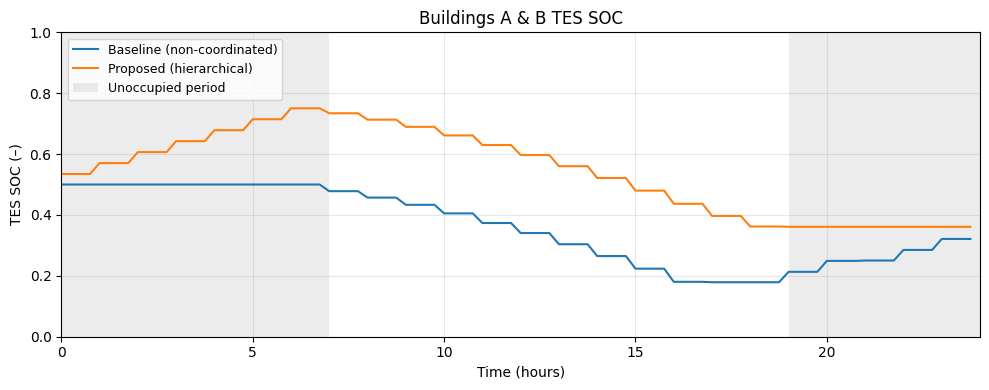

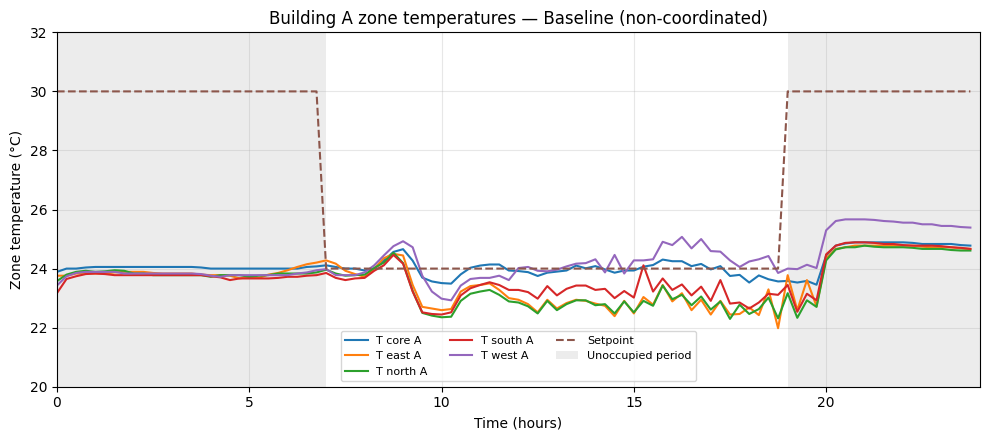

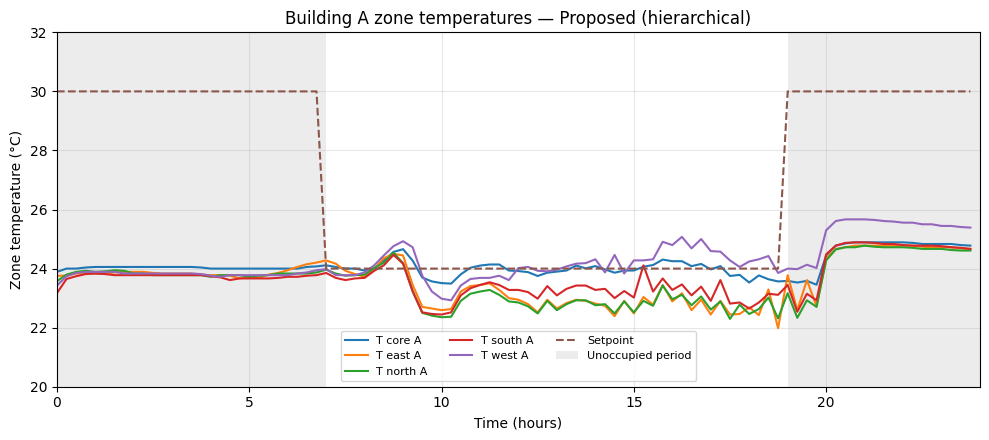

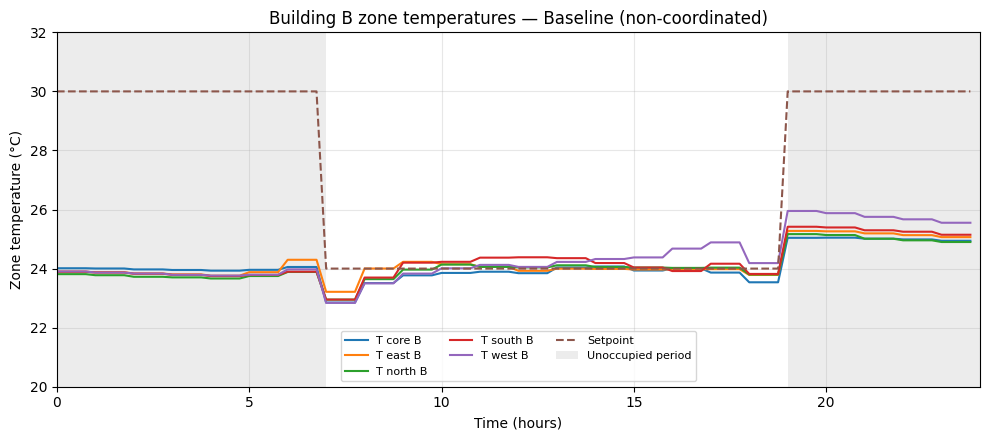

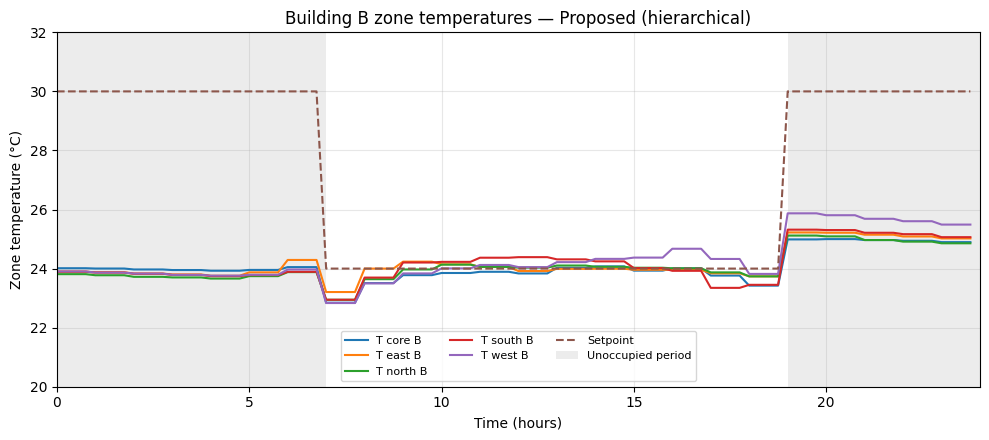

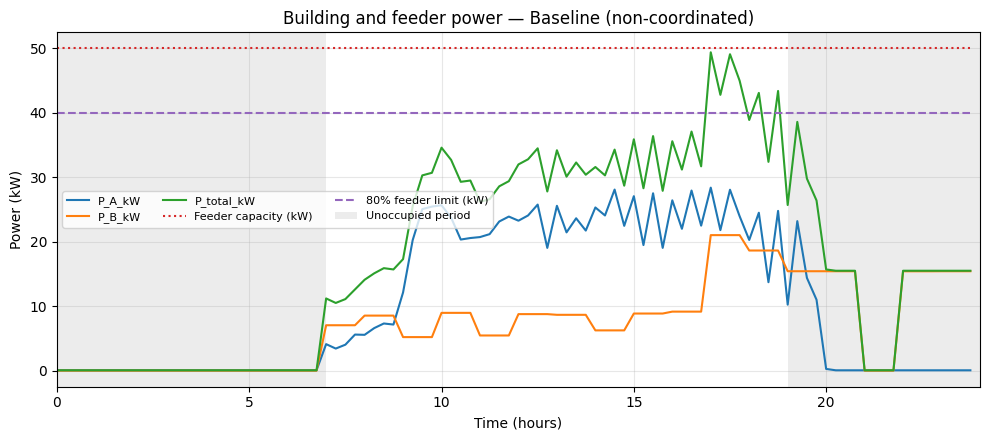

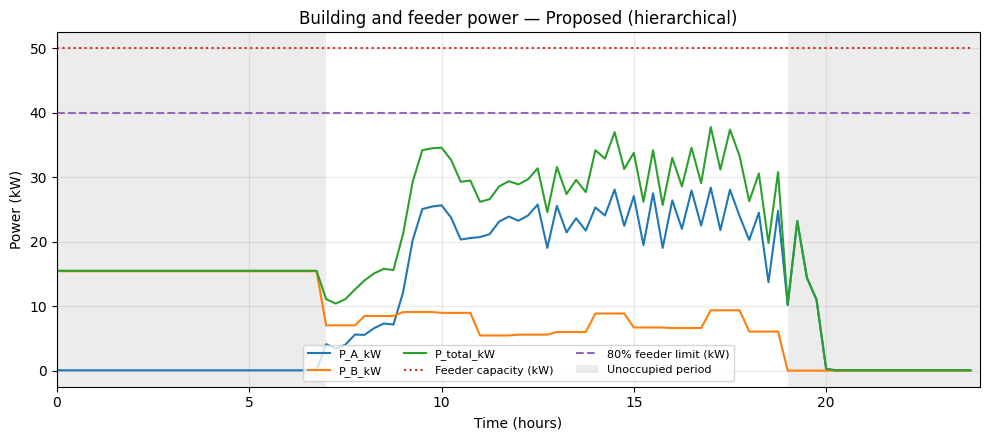

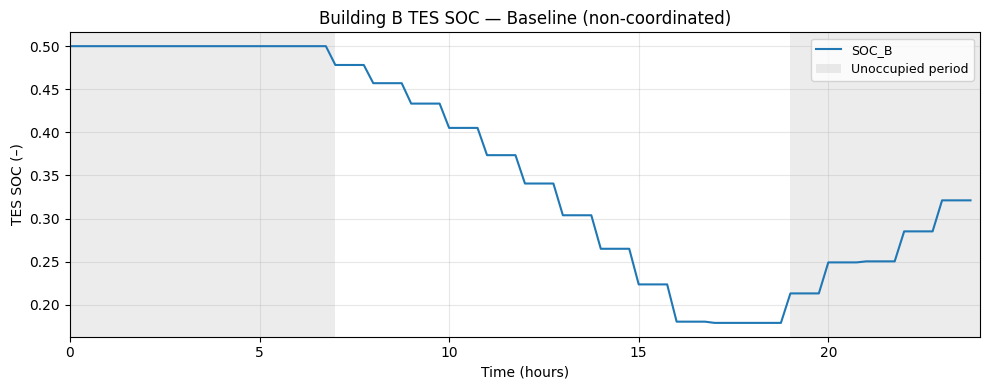

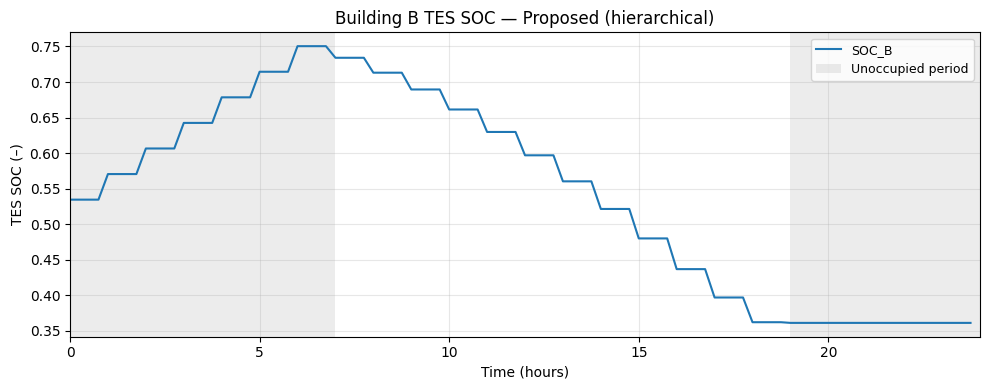

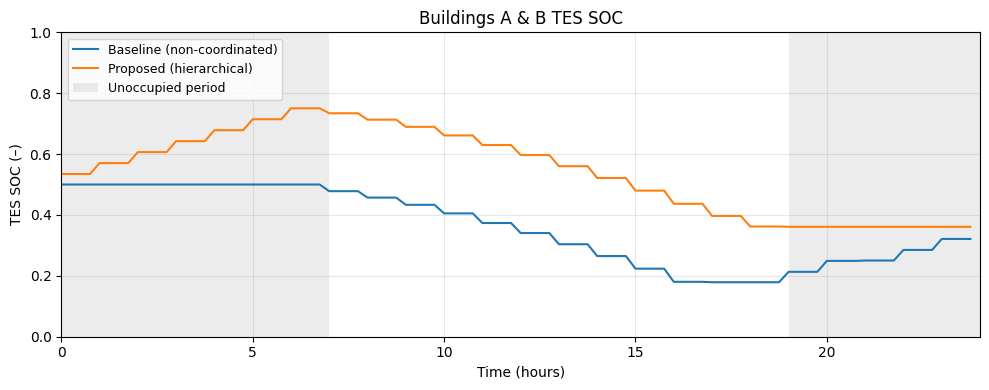

In [163]:
# Requested time-series plots
plot_zone_temps(df_base, "A", "Baseline (non-coordinated)")
plot_zone_temps(df_prop, "A", "Proposed (hierarchical)")
plot_zone_temps(df_base, "B", "Baseline (non-coordinated)") # , setpoint_C=25.0
plot_zone_temps(df_prop, "B", "Proposed (hierarchical)") # , setpoint_C=25.0

plot_powers(df_base, "Baseline (non-coordinated)", limit_frac=0.8)
plot_powers(df_prop, "Proposed (hierarchical)", limit_frac=0.8)

plot_soc(df_base, "Baseline (non-coordinated)")
plot_soc(df_prop, "Proposed (hierarchical)")

plot_soc_two(df_base, df_prop, "SOC_B", "SOC_B")


## Comparison plot

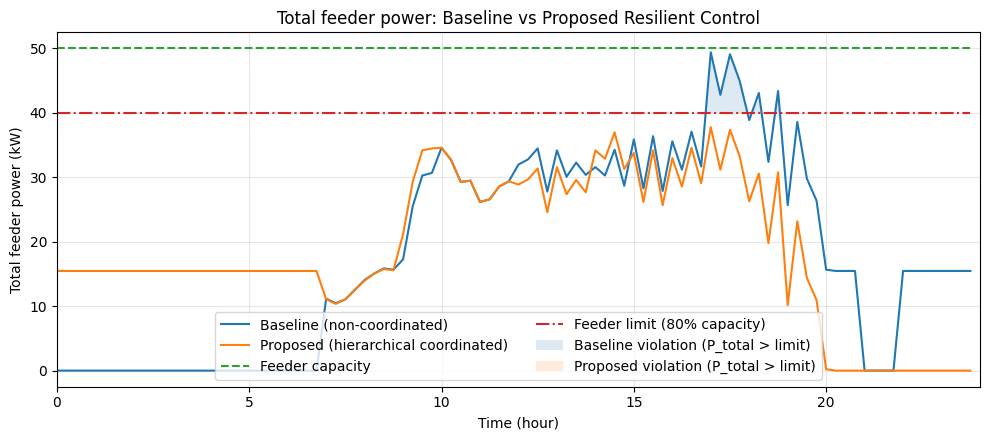

In [164]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assumes you already have:
baseline_df  = df_base
proposed_df  = df_prop

# --- X axis (hours 0–24) ---
x1 = baseline_df["sim_hours"].to_numpy()
x2 = proposed_df["sim_hours"].to_numpy()

# If your sim_hours is not exactly 0–24 (e.g., starts at 212), uncomment:
# x1 = x1 - x1[0]
# x2 = x2 - x2[0]

# --- Feeder capacity and 80% limit (use baseline; typically identical across scenarios) ---
cap = baseline_df["feeder_capacity_kW"].to_numpy()
lim = 0.80 * cap

# --- Total feeder power overlay ---
p1 = baseline_df["P_total_kW"].to_numpy()
p2 = proposed_df["P_total_kW"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(x1, p1, label="Baseline (non-coordinated)")
ax.plot(x2, p2, label="Proposed (hierarchical coordinated)")

# Capacity + limit lines
ax.plot(x1, cap, linestyle="--", label="Feeder capacity")
ax.plot(x1, lim, linestyle="-.", label="Feeder limit (80% capacity)")

# Optional: highlight violation periods for each scenario (transparent shading)
# Baseline violations
mask1 = p1 > lim
ax.fill_between(x1, lim, p1, where=mask1, alpha=0.15, interpolate=True,
                label="Baseline violation (P_total > limit)")
# Proposed violations
# (use the limit defined on baseline timeline; assumes same time grid)
mask2 = p2 > lim
ax.fill_between(x2, lim, p2, where=mask2, alpha=0.15, interpolate=True,
                label="Proposed violation (P_total > limit)")

ax.set_xlim(0, 24)
ax.set_xlabel("Time (hour)")
ax.set_ylabel("Total feeder power (kW)")
ax.set_title("Total feeder power: Baseline vs Proposed Resilient Control")
ax.grid(True, alpha=0.3)

# De-duplicate legend entries (fill_between can add duplicates)
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="best", ncol=2, frameon=True)

plt.tight_layout()
plt.show()

## Export (optional)

In [165]:
# Optional: export summary tables and figures
out_dir = Path("hierarchical_postprocess_outputs")
out_dir.mkdir(exist_ok=True)

metrics_df.to_csv(out_dir / "full_metrics_summary.csv", index=False)
compare_df.to_csv(out_dir / "key_metrics_comparison.csv", index=False)

# Save figures as PNG
for name, fig in {
    "A_zone_temps_baseline": plot_zone_temps(df_base, "A", "Baseline"),
    "A_zone_temps_proposed": plot_zone_temps(df_prop, "A", "Proposed"),
    "B_zone_temps_baseline": plot_zone_temps(df_base, "B", "Baseline"),
    "B_zone_temps_proposed": plot_zone_temps(df_prop, "B", "Proposed"),
    "power_baseline": plot_powers(df_base, "Baseline"),
    "power_proposed": plot_powers(df_prop, "Proposed"),
    "soc_baseline": plot_soc(df_base, "Baseline"),
    "soc_proposed": plot_soc(df_prop, "Proposed"),
}.items():
    fig.savefig(out_dir / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print("Saved outputs to:", out_dir.resolve())


Saved outputs to: C:\Users\guowenli\Desktop\Github\multi-building-resilient-control\connected_AB_schedule\results\hierarchical_postprocess_outputs
